<a href="https://colab.research.google.com/github/imjoseangel/sandbox/blob/devel/getting_started_voyage_3_large.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting started with flexible dimensions and quantization using Voyage models

Voyage models have been trained with both [Matryoshka representation learning](https://arxiv.org/abs/2205.13147) as well as [quantization awareness](https://pytorch.org/blog/quantization-aware-training/). The combination of the two gives you maximum flexibility when building your retrieval/RAG applications, allowing you to choose along a spectrum of different options between significantly reduced storage costs (at slightly reduced retrieval quality) and maximum retrieval retrieval performance. The figure below compares the retrieval quality versus storage costs for different general-purpose embedding models:

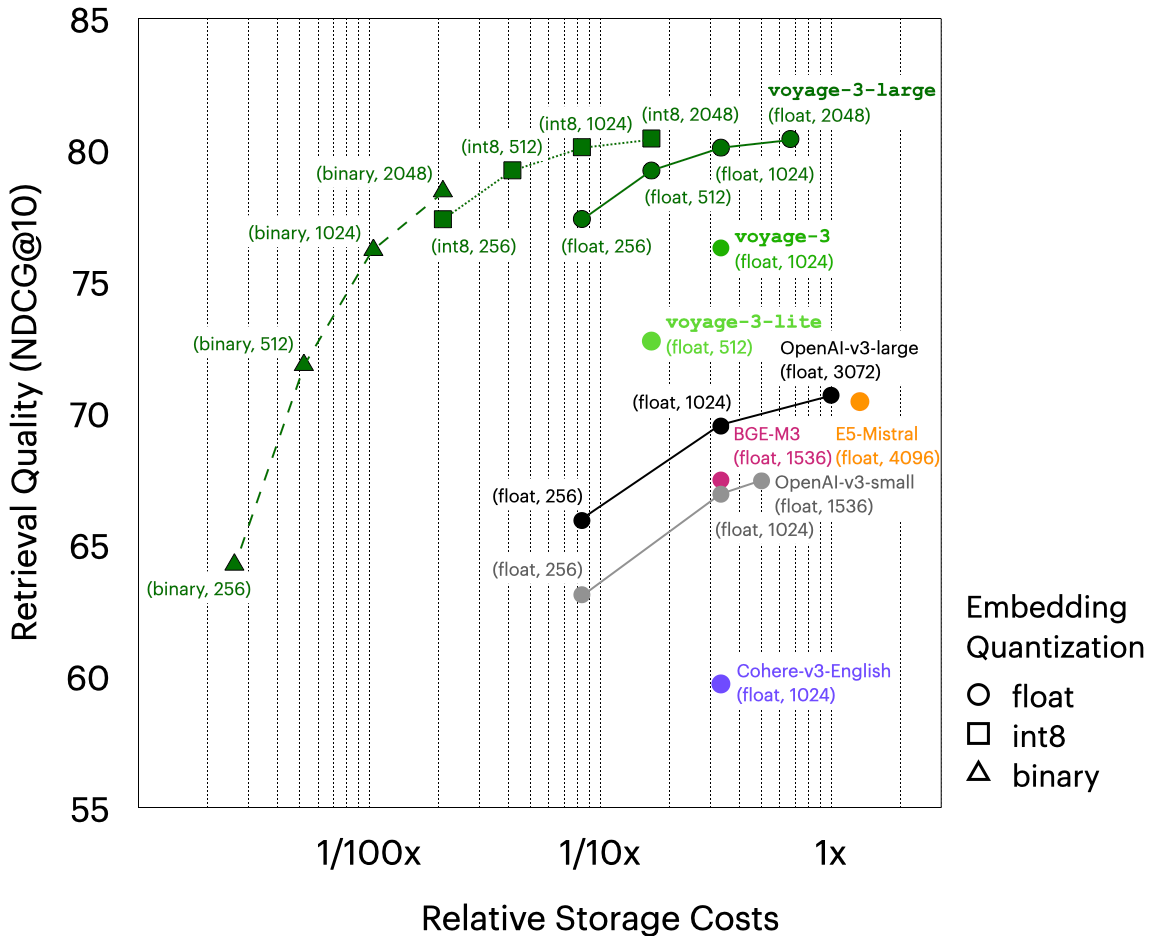

[`voyage-3-large`](https://blog.voyageai.com/2025/01/07/voyage-3-large/) performs better than OpenAI's `text-embedding-3-large` than 1/192 of the storage costs!

**Matryoshka Representation Learning (MRL)**

MRL is a method for creating embeddings where a single vector contains a nested hierarchy of embeddings, each corresponding to a different dimensionality. This structure allows the vector to encode information at multiple granularities within the same space, much like a matryoshka doll, where smaller/shorter embeddings fit within larger ones.

The diagram below illustrates this in action: an output embedding generated by `voyage-3-large` can be decomposed into 256d, 512d, 1024d, or 2048d vectors, each of which captures the full semantics of the input text. Higher-dimensional embeddings are more semantically rich and tend to capture more nuance, while smaller embeddings reduce storage and compute costs when performing retrieval:

matryoshka_representation_learning.svg

In the `Retrieval Quality vs. Relative Storage Costs` diagram above, MRL corresponds to lines connecting individual "groups" of points.

**Quantization-aware training**

Quantization is the process of reducing the precision of the values (e.g., from 32-bit floating-point to 8-bit integers) used to represent the output embeddings. Like MRL, this can be used to reduce the memory footprint and computational requirements needed by the embeddings during retrieval.

Naïve training strategies can result in significantly reduced representational power post-quantization. With quantization-aware training, the forward pass applies quantization operations to the final output embedding; backpropogation through these operations ensures that the model "learns" to perform well even with quantized representations.

In the `Retrieval Quality vs. Relative Storage Costs` diagram above, the shapes of the points correspond to different levels of quantization (`binary`, `int8`, and `float32`).



## 0. Add your API key to Colab secrets

To run this notebook, you'll need a __Voyage API key__. If you don't have a Voyage API key yet, you can create one [here](https://dash.voyageai.com).

(If you're running this notebook locally, you can skip the remainder of this step.)

By default, this notebook uses the Google Colab environment. You can add your API key to the Colab Secrets manager to securely store it:

1. Open your Google Colab notebook and click on the 🔑 **Secrets** tab in the left panel.
   
   <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="The Secrets tab is found on the left panel." width=50%>

2. Create a new secret with the name `VOYAGE_API_KEY`.
3. Copy/paste your API key into the `Value` input box of `VOYAGE_API_KEY`.
4. Toggle the button on the left to allow notebook access to the secret.

## 1. Install packages

Now it's time to get started -- let's begin by installing some packages. For this notebook, all you'll need:

- `voyageai` for calling accessing the multimodal model via the Voyage API

In [ ]:
!pip install voyageai>=0.3.0

For this notebook, we'll use `voyage-3-large` as the embedding model. You can see a full list of embedding models available to you on the [Voyage AI documentation](https://docs.voyageai.com/docs/embeddings).

In [ ]:
MODEL_NAME = "voyage-3-large"

## 2. Create a synchronous Voyage client

(If you're running this notebook locally, uncomment the cell below and run it in place of the second cell.)

In [ ]:
#import os
#api_key = os.getenv("VOYAGE_API_KEY")

In [ ]:
from google.colab import userdata
api_key = userdata.get("VOYAGE_API_KEY")

In [ ]:
from voyageai import Client
vo = Client(api_key=api_key)

We'll start by generating some standard vectors (1024 dimensions, `float32` type) over some sample data:

In [ ]:
texts = [
    "The Mediterranean diet emphasizes fish, olive oil, and vegetables, believed to reduce chronic diseases.",
    "Photosynthesis in plants converts light energy into glucose and produces essential oxygen.",
    "20th-century innovations, from radios to smartphones, centered on electronic advancements.",
    "Rivers provide water, irrigation, and habitat for aquatic species, vital for ecosystems.",
    "Apple’s conference call to discuss fourth fiscal quarter results and business updates is scheduled for Thursday, November 2, 2023 at 2:00 p.m. PT / 5:00 p.m. ET.",
    "Shakespeare's works, like 'Hamlet' and 'A Midsummer Night's Dream,' endure in literature."
]

In [ ]:
result = vo.embed(
    texts,
    model=MODEL_NAME,
    input_type="document"
).embeddings

We'll specify a helper function which prints the dimensionality and data type of these embeddings:

In [ ]:
from typing import Union

def print_embedding_info(embeddings: list[Union[int, float]]):
    if isinstance(embeddings[0], list):
        return print_embedding_info(embeddings[0])
    print(f"Dimensionality: {len(embeddings)}")
    print(f"Data type: {type(embeddings[0])}")

In [ ]:
print_embedding_info(result)

Dimensionality: 1024
Data type: <class 'float'>


## 3. Specifying embedding dimension using the Voyage client

In the call to `embed`, we can specify the number of output dimensions that we'd like the embeddings to have:

In [ ]:
result_256d = vo.embed(
    texts,
    model=MODEL_NAME,
    input_type="document",
    output_dimension=256
).embeddings

We can confirm that these embeddings do indeed have the desired dimensionality:

In [ ]:
print_embedding_info(result_256d)

Dimensionality: 256
Data type: <class 'float'>


Recall from earlier that Matryoshka embeddings are trained to allow for different embedding dimensions. We can verify this by showing that the first 256 dimensions of `result` and `result_256d` differ by a scaling factor due to normalization.

In [ ]:
import numpy as np

normalize = lambda x: x / (np.linalg.norm(x) + 1e-6)  # Add a small epsilon value to prevent ZeroDivisionError exceptions
result_ = [normalize(r[:256]) for r in result]

In [ ]:
print(f"Vectors close?: {np.allclose(result_256d, result_)}")

Vectors close?: True


## 4. Specifying embedding data type using the Voyage client



In addition to the number of output dimensions, we can also set the output data type in our call to `embed`. We can use one of five values:
- `float`
- `int8`
- `uint8`
- `binary` (offset binary)
- `ubinary`

### 4a. Byte (`int8`) embeddings

Let's first go over generating 8-bit quantized embeddings using the `int8` data type:

In [ ]:
result_int8 = vo.embed(
    texts,
    model=MODEL_NAME,
    input_type="document",
    output_dtype="int8"
).embeddings

Again, we can confirm that these embeddings are indeed the correct data type:

In [ ]:
print_embedding_info(result_int8)

Dimensionality: 1024
Data type: <class 'int'>


### 4b. Binary (`ubinary`) embeddings

We can do the same for binary embeddings:

In [ ]:
result_binary = vo.embed(
    texts,
    model=MODEL_NAME,
    input_type="document",
    output_dtype="ubinary"
).embeddings

It's important to note that binary embeddings are returned in a bit-packed format, i.e. eight values are packed into a single element in the returned vector. We can take the first few elements of one of the embeddings to verify this:

In [ ]:
result_binary[0][:8]

[72, 55, 200, 243, 131, 101, 73, 33]

We can unpack these values using Numpy's `unpackbits` function. We'll first convert the embeddings to a `uint8` array because we specified `output_dtype="ubinary"`:

In [ ]:
import numpy as np

def unpack_binary_embeddings(embeddings: list[int]):
    embeddings = np.array(embeddings, dtype=np.uint8)
    embeddings = np.unpackbits(embeddings)
    return embeddings.astype(bool).tolist()

result_binary = [unpack_binary_embeddings(v) for v in result_binary]

Looking at the resulting values, we can now see that they are indeed binary vectors:

In [ ]:
result_binary[0][:8]

[False, True, False, False, True, False, False, False]

In [ ]:
print_embedding_info(result_binary)

Dimensionality: 1024
Data type: <class 'bool'>


Searches across binary vectors can be done with Hamming distance, which is equivalent to cosine distance:

In [ ]:
import numpy as np

def binary_cos_sim(a: np.array, b: np.array):
    return np.count_nonzero(a != b)

In [ ]:
query = "When is Apple's conference call scheduled?"
query_embedding = vo.embed(
    [query],
    model="voyage-3-large",
    input_type="query",
    output_dtype="ubinary"
).embeddings[0]
query_embedding = unpack_binary_embeddings(query_embedding)

In [ ]:
dists = []
for document_embedding in result_binary:
    dists.append(binary_cos_sim(np.array(query_embedding), np.array(document_embedding)))
print(f"Best match: {texts[np.argmin(dists)]}")

Best match: Apple’s conference call to discuss fourth fiscal quarter results and business updates is scheduled for Thursday, November 2, 2023 at 2:00 p.m. PT / 5:00 p.m. ET.


## 5. Storing quantized vectors in vector databases

Here is a (non-comprehensive) list of vector databases that support quantized vectors out-of-the-box:

| <p>Vector database</p> | <p>`int8` support</p> | <p>`binary` support</p> |
| --------------- | -------------- | ---------------- |
| <p>[Elasticsearch](https://www.elastic.co/elasticsearch)</p> | <p>✅</p> | <p>✅</p> |
| <p>[Opensearch](https://opensearch.org/)</p> | <p>✅</p> | <p>✅</p> |
| <p>[Vespa](https://vespa.ai/)</p> | <p>✅</p> | <p>✅</p> |
| <p>[Milvus](https://milvus.io/)</p> | <p>✅<sup>1</sup></p> | <p>✅</p> |
| <p>[Qdrant](https://qdrant.tech)</p> | <p>✅<sup>1</sup></p> | <p>✅<sup>1</sup></p> |
| <p>[pgvector](https://github.com/pgvector/pgvector)</p> | <p>✅<sup>1</sup></p> | <p>✅<sup>1</sup></p> |
| <p>[Weaviate](https://weaviate.io)</p> | <p>—</p> | <p>✅<sup>1</sup></p> |

<sup>1</sup> Quantization is performed at the index layer (after inserting `float` vectors) rather than at the schema layer.

Please feel free to reach out to us through email (contact@voyageai.com) or through [Discord](https://discord.gg/zAU7GQEmvT) if you find anything missing from this table.

The rest of this section will contain standalone retrieval examples with each vector database.

### 5a. Storing quantized vectors in Elasticsearch/Opensearch

___Coming soon!___

### 5b. Storing quantized vectors in Vespa

___Coming soon!___

### 5c. Storing binary vectors in Milvus

Milvus supports binary vectors through the `BINARY_VECTOR` data type. Let's see how we can use

Some prep work first:

In [ ]:
!pip install -U voyageai pymilvus[model]

In [ ]:
#import os
#voyage_api_key = os.getenv("VOYAGE_API_KEY")
from google.colab import userdata
voyage_api_key = userdata.get("VOYAGE_API_KEY")

In [ ]:
texts = [
    "The Mediterranean diet emphasizes fish, olive oil, and vegetables, believed to reduce chronic diseases.",
    "Photosynthesis in plants converts light energy into glucose and produces essential oxygen.",
    "20th-century innovations, from radios to smartphones, centered on electronic advancements.",
    "Rivers provide water, irrigation, and habitat for aquatic species, vital for ecosystems.",
    "Apple’s conference call to discuss fourth fiscal quarter results and business updates is scheduled for Thursday, November 2, 2023 at 2:00 p.m. PT / 5:00 p.m. ET.",
    "Shakespeare's works, like 'Hamlet' and 'A Midsummer Night's Dream,' endure in literature."
]

In [ ]:
from pymilvus import DataType, MilvusClient
from pymilvus.model.dense import VoyageEmbeddingFunction

# Milvus client object for interfacing with Milvus local/lite
milvus_client = MilvusClient("./voyage.db")

# Create a schema, specifying the `BINARY_VECTOR` data type for our vector field
schema = milvus_client.create_schema(auto_id=True, enable_dynamic_fields=True)
schema.add_field(field_name="pk", datatype=DataType.VARCHAR, is_primary=True, auto_id=True, max_length=100)
schema.add_field(field_name="binary_vector", datatype=DataType.BINARY_VECTOR, dim=512)

# Specify index parameters for the vector field
index_params = milvus_client.prepare_index_params()
index_params.add_index(
    field_name="binary_vector",
    index_name="binary_vector_index",
    index_type="BIN_FLAT",  # Milvus local mode only supports brute-force indexing of binary vectors
    metric_type="HAMMING",  # Hamming distance is equivalent to cosine similarity for binary (boolean) vectors
    params={"nlist": 128}
)

# Create the collection with the given schema and index params
milvus_client.create_collection(
    collection_name="voyage_test",
    schema=schema,
    index_params=index_params
)

In [ ]:
# Embed documents using the built-in Voyage embedding function from `pymilvus`
voyage_ef = VoyageEmbeddingFunction(
    model_name="voyage-3-large",
    api_key=voyage_api_key,
    embedding_type="ubinary",
    dimension=512
)
embeddings = voyage_ef.encode_documents(texts)

# Insert the resulting binary embeddings
res = milvus_client.insert(
    collection_name="voyage_test",
    data=embeddings
)

# Next steps

Try `voyage-3-large` on your own data today! The first 200M tokens are on us. If you have any follow-up questions, or if you're interested in fine-tuned embeddings, feel free to reach out to use at contact@voyageai.com.

Feel free to follow us on [X (Twitter)](https://x.com/VoyageAI) and [LinkedIn](https://www.linkedin.com/company/voyageai/), and join our [Discord](https://discord.gg/zAU7GQEmvT) for more updates.